# **Noise Seed 1**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)

# Add noise to the data
noise_seed = 1  # Change to 2 and 3 for other runs
rng = np.random.default_rng(noise_seed)
noise = rng.normal(0, 0.5, u_data.shape)
u_data = u_data + jnp.array(noise)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 900000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('noisy_spatial_checkpoints/ns_3.93e-8_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/900000, Loss: 5.092298
  BC Loss: 0.048406, Physics Loss: 0.192680, Data Loss: 0.000295
  Current kappa: 3.99e-08 m^2/s
Iteration 2000/900000, Loss: 4.270880
  BC Loss: 0.040394, Physics Loss: 0.186944, Data Loss: 0.000223
  Current kappa: 4.00e-08 m^2/s
Iteration 3000/900000, Loss: 3.222502
  BC Loss: 0.029734, Physics Loss: 0.216223, Data Loss: 0.000164
  Current kappa: 4.01e-08 m^2/s
Iteration 4000/900000, Loss: 1.427810
  BC Loss: 0.013144, Physics Loss: 0.093475, Data Loss: 0.000100
  Current kappa: 4.03e-08 m^2/s
Iteration 5000/900000, Loss: 0.765452
  BC Loss: 0.005550, Physics Loss: 0.196220, Data Loss: 0.000071
  Current kappa: 4.05e-08 m^2/s
Iteration 6000/900000, Loss: 0.271199
  BC Loss: 0.002016, Physics Loss: 0.059685, Data Loss: 0.000050
  Current kappa: 4.07e-08 m^2/s
Iteration 7000/900000, Loss: 0.141258
  BC Loss: 0.001091, Physics Loss: 0.023600, Data Loss: 0.000043
  Current kappa: 4.10e-08 m^2/s
Iteration 8000/900000, Loss: 0.172463
  BC Loss: 0.0007

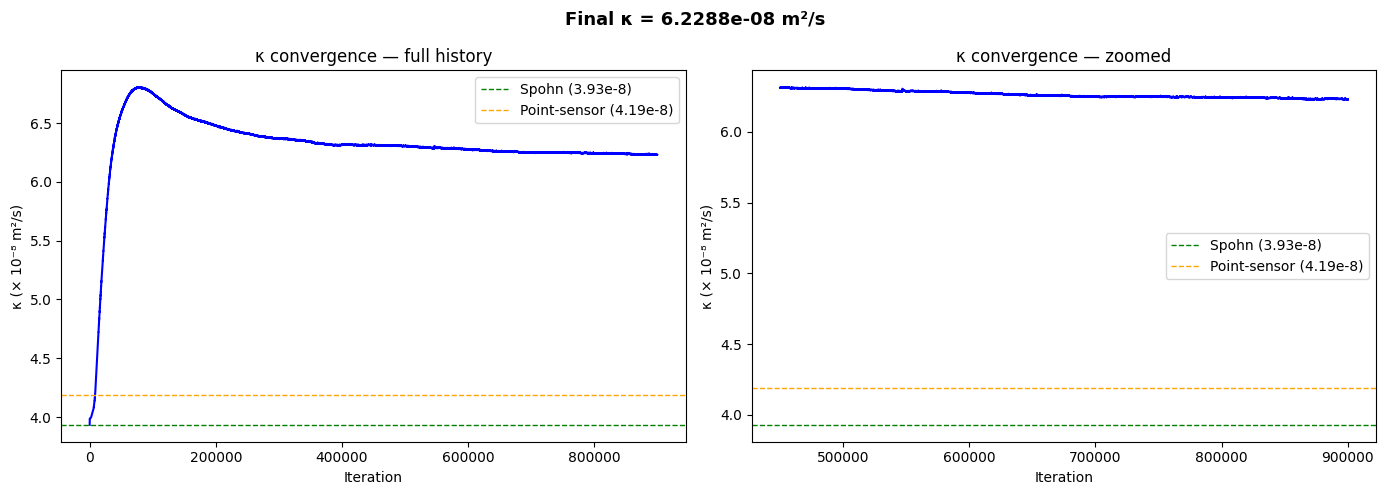

Final κ:          6.2288e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +58.5%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noisy_spatial_graphs/kappa_ns_3.93e-8_run1.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

# **Noise Seed 2**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)

# Add noise to the data
noise_seed = 2  # Change to 2 and 3 for other runs
rng = np.random.default_rng(noise_seed)
noise = rng.normal(0, 0.5, u_data.shape)
u_data = u_data + jnp.array(noise)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 1000000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('noisy_spatial_checkpoints/ns_3.93e-8_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/1000000, Loss: 5.093108
  BC Loss: 0.048402, Physics Loss: 0.192594, Data Loss: 0.000302
  Current kappa: 3.99e-08 m^2/s
Iteration 2000/1000000, Loss: 4.272177
  BC Loss: 0.040397, Physics Loss: 0.187050, Data Loss: 0.000227
  Current kappa: 4.00e-08 m^2/s
Iteration 3000/1000000, Loss: 3.223490
  BC Loss: 0.029738, Physics Loss: 0.216151, Data Loss: 0.000168
  Current kappa: 4.01e-08 m^2/s
Iteration 4000/1000000, Loss: 1.427721
  BC Loss: 0.013139, Physics Loss: 0.093614, Data Loss: 0.000101
  Current kappa: 4.03e-08 m^2/s
Iteration 5000/1000000, Loss: 0.614280
  BC Loss: 0.005527, Physics Loss: 0.049082, Data Loss: 0.000063
  Current kappa: 4.05e-08 m^2/s
Iteration 6000/1000000, Loss: 2.524556
  BC Loss: 0.002392, Physics Loss: 2.214628, Data Loss: 0.000354
  Current kappa: 4.07e-08 m^2/s
Iteration 7000/1000000, Loss: 0.159985
  BC Loss: 0.001100, Physics Loss: 0.040357, Data Loss: 0.000048
  Current kappa: 4.11e-08 m^2/s
Iteration 8000/1000000, Loss: 0.104111
  BC Loss

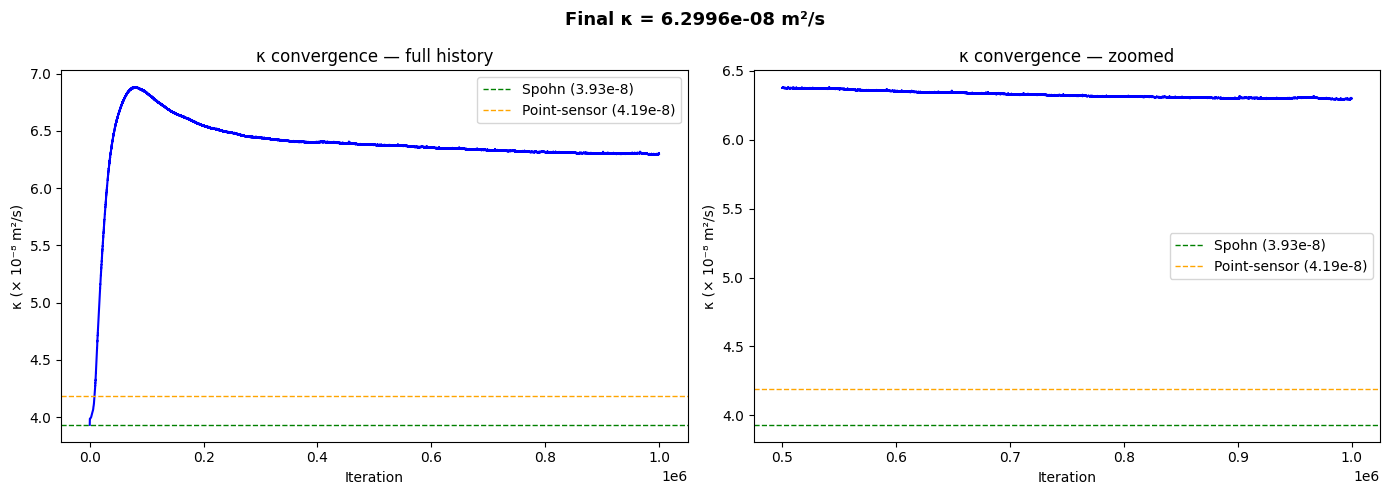

Final κ:          6.2996e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +60.3%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noisy_spatial_graphs/kappa_ns_3.93e-8_run2.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

# **Noise Seed 3**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)

# Add noise to the data
noise_seed = 3  # Change to 2 and 3 for other runs
rng = np.random.default_rng(noise_seed)
noise = rng.normal(0, 0.5, u_data.shape)
u_data = u_data + jnp.array(noise)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 1000000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('noisy_spatial_checkpoints/ns_3.93e-8_run03.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

Iteration 1000/1000000, Loss: 5.092617
  BC Loss: 0.048405, Physics Loss: 0.193159, Data Loss: 0.000295
  Current kappa: 3.99e-08 m^2/s
Iteration 2000/1000000, Loss: 4.271462
  BC Loss: 0.040402, Physics Loss: 0.186466, Data Loss: 0.000224
  Current kappa: 4.00e-08 m^2/s
Iteration 3000/1000000, Loss: 3.223555
  BC Loss: 0.029745, Physics Loss: 0.215941, Data Loss: 0.000166
  Current kappa: 4.01e-08 m^2/s
Iteration 4000/1000000, Loss: 1.428048
  BC Loss: 0.013147, Physics Loss: 0.093435, Data Loss: 0.000100
  Current kappa: 4.03e-08 m^2/s
Iteration 5000/1000000, Loss: 0.628933
  BC Loss: 0.005527, Physics Loss: 0.064292, Data Loss: 0.000059
  Current kappa: 4.05e-08 m^2/s
Iteration 6000/1000000, Loss: 0.988149
  BC Loss: 0.002144, Physics Loss: 0.749759, Data Loss: 0.000120
  Current kappa: 4.07e-08 m^2/s
Iteration 7000/1000000, Loss: 0.407099
  BC Loss: 0.001090, Physics Loss: 0.286448, Data Loss: 0.000058
  Current kappa: 4.10e-08 m^2/s
Iteration 8000/1000000, Loss: 0.126265
  BC Loss

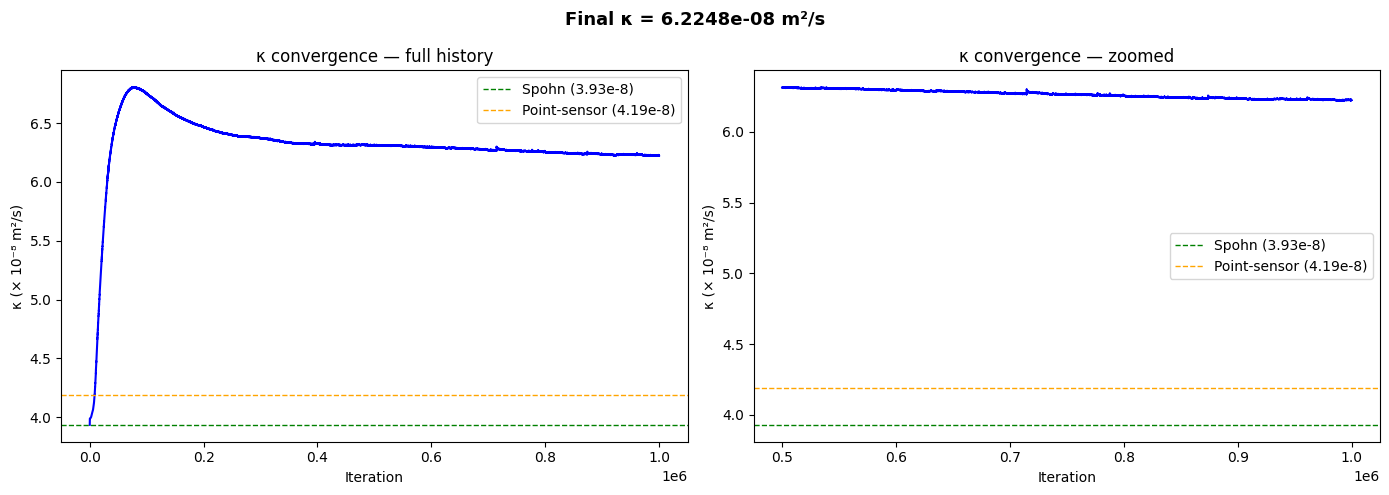

Final κ:          6.2248e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: +58.4%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noisy_spatial_graphs/kappa_ns_3.93e-8_run3.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")